https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

# Utility
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("../data/forestcover.csv")

In [4]:
print(df.columns.tolist())


['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Cover_Type']


In [5]:
# Make column names consistent and Python-friendly
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [6]:
print(df.columns.tolist())


['elevation', 'aspect', 'slope', 'horizontal_distance_to_hydrology', 'vertical_distance_to_hydrology', 'horizontal_distance_to_roadways', 'hillshade_9am', 'hillshade_noon', 'hillshade_3pm', 'horizontal_distance_to_fire_points', 'wilderness_area1', 'wilderness_area2', 'wilderness_area3', 'wilderness_area4', 'soil_type1', 'soil_type2', 'soil_type3', 'soil_type4', 'soil_type5', 'soil_type6', 'soil_type7', 'soil_type8', 'soil_type9', 'soil_type10', 'soil_type11', 'soil_type12', 'soil_type13', 'soil_type14', 'soil_type15', 'soil_type16', 'soil_type17', 'soil_type18', 'soil_type19', 'soil_type20', 'soil_type21', 'soil_type22', 'soil_type23', 'soil_type24', 'soil_type25', 'soil_type26', 'soil_type27', 'soil_type28', 'soil_type29', 'soil_type30', 'soil_type31', 'soil_type32', 'soil_type33', 'soil_type34', 'soil_type35', 'soil_type36', 'soil_type37', 'soil_type38', 'soil_type39', 'soil_type40', 'cover_type']


In [7]:
print(df.shape)
print(df.dtypes)
print(df.info())
print(df.describe().T)

(581012, 55)
elevation                             int64
aspect                                int64
slope                                 int64
horizontal_distance_to_hydrology      int64
vertical_distance_to_hydrology        int64
horizontal_distance_to_roadways       int64
hillshade_9am                         int64
hillshade_noon                        int64
hillshade_3pm                         int64
horizontal_distance_to_fire_points    int64
wilderness_area1                      int64
wilderness_area2                      int64
wilderness_area3                      int64
wilderness_area4                      int64
soil_type1                            int64
soil_type2                            int64
soil_type3                            int64
soil_type4                            int64
soil_type5                            int64
soil_type6                            int64
soil_type7                            int64
soil_type8                            int64
soil_type9         

In [10]:
missing_counts = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)

print(missing_table.head(20))

total_missing = df.isna().sum().sum()
print("\nTotal missing values:", total_missing)

             missing_count  missing_percent
elevation                0              0.0
soil_type28              0              0.0
soil_type17              0              0.0
soil_type18              0              0.0
soil_type19              0              0.0
soil_type20              0              0.0
soil_type21              0              0.0
soil_type22              0              0.0
soil_type23              0              0.0
soil_type24              0              0.0
soil_type25              0              0.0
soil_type26              0              0.0
soil_type27              0              0.0
soil_type29              0              0.0
soil_type15              0              0.0
soil_type30              0              0.0
soil_type31              0              0.0
soil_type32              0              0.0
soil_type33              0              0.0
soil_type34              0              0.0

Total missing values: 0


In [9]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [11]:
target_col = "cover_type"

print("\nTarget value counts:")
print(df[target_col].value_counts().sort_index())

print("\nTarget proportions:")
print((df[target_col].value_counts(normalize=True).sort_index() * 100).round(2))



Target value counts:
cover_type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Target proportions:
cover_type
1    36.46
2    48.76
3     6.15
4     0.47
5     1.63
6     2.99
7     3.53
Name: proportion, dtype: float64


In [12]:
# XGBoost expects class labels from 0 to number_of_classes - 1.
# Original Cover_Type labels are 1 to 7.
df[target_col] = df[target_col] - 1

print("\nTarget values after shifting from 1-7 to 0-6:")
print(df[target_col].value_counts().sort_index())



Target values after shifting from 1-7 to 0-6:
cover_type
0    211840
1    283301
2     35754
3      2747
4      9493
5     17367
6     20510
Name: count, dtype: int64


In [13]:
feature_cols = [col for col in df.columns if col != target_col]

# Wilderness and soil columns are already one-hot encoded.
wilderness_cols = [col for col in feature_cols if col.startswith("wilderness_area")]
soil_cols = [col for col in feature_cols if col.startswith("soil_type")]

# Continuous numeric columns are the remaining feature columns.
binary_encoded_cols = wilderness_cols + soil_cols
continuous_cols = [col for col in feature_cols if col not in binary_encoded_cols]


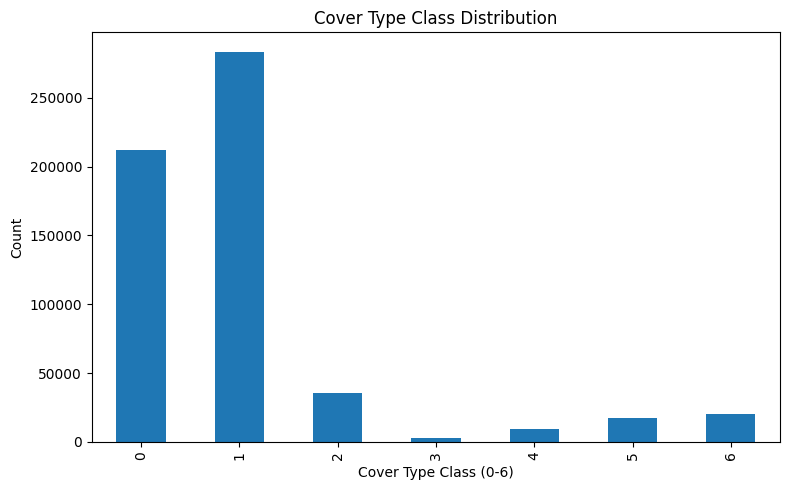

In [14]:
plt.figure(figsize=(8, 5))
df[target_col].value_counts().sort_index().plot(kind="bar")
plt.title("Cover Type Class Distribution")
plt.xlabel("Cover Type Class (0-6)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [17]:
X = df.drop(columns=[target_col])
y = df[target_col]


In [16]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (581012, 54)
y shape: (581012,)


In [18]:
# First cut:
# 80% train+validation, 20% test

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
# Second split:
# From train_val, create 75% train and 25% validation.

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

In [21]:
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (348606, 54) (348606,)
Validation shape: (116203, 54) (116203,)
Test shape: (116203, 54) (116203,)


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("scale_continuous", StandardScaler(), continuous_cols),
        ("pass_binary_encoded", "passthrough", binary_encoded_cols)
    ],
    remainder="drop"
)

In [23]:
print(preprocessor)


ColumnTransformer(transformers=[('scale_continuous', StandardScaler(),
                                 ['elevation', 'aspect', 'slope',
                                  'horizontal_distance_to_hydrology',
                                  'vertical_distance_to_hydrology',
                                  'horizontal_distance_to_roadways',
                                  'hillshade_9am', 'hillshade_noon',
                                  'hillshade_3pm',
                                  'horizontal_distance_to_fire_points']),
                                ('pass_binary_encoded', 'passthrough',
                                 ['wilderness_area1', 'wil...
                                  'soil_type1', 'soil_type2', 'soil_type3',
                                  'soil_type4', 'soil_type5', 'soil_type6',
                                  'soil_type7', 'soil_type8', 'soil_type9',
                                  'soil_type10', 'soil_type11', 'soil_type12',
                      

In [24]:
xgb_baseline = XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [25]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_baseline)
    ]
)

In [26]:

print("Training Baseline XGBoost Model")

baseline_pipeline.fit(X_train, y_train)

val_pred_baseline = baseline_pipeline.predict(X_val)

baseline_accuracy = accuracy_score(y_val, val_pred_baseline)
baseline_f1_macro = f1_score(y_val, val_pred_baseline, average="macro")
baseline_precision_macro = precision_score(y_val, val_pred_baseline, average="macro")
baseline_recall_macro = recall_score(y_val, val_pred_baseline, average="macro")


Training Baseline XGBoost Model


In [27]:
print("\nBaseline Validation Metrics:")
print("Accuracy:", baseline_accuracy)
print("F1 Macro:", baseline_f1_macro)
print("Precision Macro:", baseline_precision_macro)
print("Recall Macro:", baseline_recall_macro)

print("\nBaseline Classification Report:")
print(classification_report(y_val, val_pred_baseline))


Baseline Validation Metrics:
Accuracy: 0.8688243849126098
F1 Macro: 0.8519775932545374
Precision Macro: 0.8843506886108257
Recall Macro: 0.8302273974629332

Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     42368
           1       0.86      0.90      0.88     56660
           2       0.90      0.91      0.90      7151
           3       0.90      0.88      0.89       549
           4       0.87      0.55      0.67      1899
           5       0.85      0.82      0.84      3474
           6       0.95      0.91      0.93      4102

    accuracy                           0.87    116203
   macro avg       0.88      0.83      0.85    116203
weighted avg       0.87      0.87      0.87    116203



In [28]:
xgb_for_tuning = XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)


In [29]:
tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_for_tuning)
    ]
)

param_distributions = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [4, 6, 8, 10],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    "model__reg_alpha": [0, 0.01, 0.1],
    "model__reg_lambda": [1, 1.5, 2, 3]
}

In [30]:
random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
print("Starting Hyperparameter Tuning")
print("=" * 80)

random_search.fit(X_train, y_train)

print("\nBest CV Score:")
print(random_search.best_score_)

print("\nBest Parameters:")
print(random_search.best_params_)

In [ ]:
best_model = random_search.best_estimator_

val_pred_tuned = best_model.predict(X_val)

tuned_accuracy = accuracy_score(y_val, val_pred_tuned)
tuned_f1_macro = f1_score(y_val, val_pred_tuned, average="macro")
tuned_precision_macro = precision_score(y_val, val_pred_tuned, average="macro")
tuned_recall_macro = recall_score(y_val, val_pred_tuned, average="macro")


In [ ]:
print("Tuned Model Validation Metrics")

print("Accuracy:", tuned_accuracy)
print("F1 Macro:", tuned_f1_macro)
print("Precision Macro:", tuned_precision_macro)
print("Recall Macro:", tuned_recall_macro)

print("\nTuned Validation Classification Report:")
print(classification_report(y_val, val_pred_tuned))

In [ ]:
comparison_df = pd.DataFrame({
    "model": ["Baseline XGBoost", "Tuned XGBoost"],
    "accuracy": [baseline_accuracy, tuned_accuracy],
    "f1_macro": [baseline_f1_macro, tuned_f1_macro],
    "precision_macro": [baseline_precision_macro, tuned_precision_macro],
    "recall_macro": [baseline_recall_macro, tuned_recall_macro]
})


In [ ]:
print("Baseline vs Tuned Model Comparison")
print(comparison_df.round(4))

In [ ]:
best_params = random_search.best_params_

# Remove "model__" prefix because now we pass parameters directly to XGBClassifier
clean_best_params = {
    key.replace("model__", ""): value
    for key, value in best_params.items()
}

final_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **clean_best_params
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_xgb)
    ]
)



In [ ]:
print("Training Final Model on Train + Validation")

final_pipeline.fit(X_train_val, y_train_val)
